# Student Performance Prediction - walkthrough

Ovaj notebook je pomoćni materijal za razumevanje projekta, pripremu odbrane i kasnije pisanje formalne dokumentacije. Ne predstavlja glavni fajl za predaju i ne uvodi nove modele, treniranje, train/test split ili grafike.

## 1. Kratak opis projekta

Cilj projekta je predikcija završne ocene učenika, odnosno promenljive **G3**, na osnovu dostupnih atributa iz dataset-a `student-por.csv`.

U ovom trenutku projekat se nalazi u fazi pripreme podataka. To znači da se podaci učitavaju, proveravaju i organizuju za kasnije modelovanje, ali se model još ne trenira.

## 2. Opis dataset-a

Dataset se nalazi na putanji `data/raw/student-por.csv`.

Podaci potiču iz istraživanja školskog uspeha učenika u Portugalu. Dataset sadrži demografske, porodične, školske i ponašajne atribute učenika, kao i njihove ocene.

Važno je zapamtiti da su ocene u ovom dataset-u na skali **0-20**, a ne na skali 1-5.

- **G1** je ocena iz prvog perioda.
- **G2** je ocena iz drugog perioda.
- **G3** je završna ocena i ciljna promenljiva koju želimo da predvidimo.

In [1]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
STEP01_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
STEP02_LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
STEP02_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 3. Zašto je ovo regresioni problem?

Ovo je regresioni problem zato što je ciljna promenljiva **G3 numerička vrednost**. Model treba da predvidi brojčanu završnu ocenu učenika na skali 0-20.

Kod klasifikacije bismo predviđali klasu ili kategoriju, na primer `položio` / `nije položio`. Ovde ne predviđamo kategoriju, već konkretnu numeričku ocenu, pa je zadatak regresija.

## 4. Zašto posebno analiziramo G1 i G2?

**G1** i **G2** su prethodne ocene učenika. Pošto predstavljaju raniji uspeh istog učenika, očekivano je da budu jako povezane sa završnom ocenom **G3**.

Zbog toga će model koji koristi G1 i G2 verovatno imati bolje rezultate. Međutim, model bez G1 i G2 može biti praktično korisniji, jer omogućava raniju procenu uspeha učenika, pre nego što su prethodne periodične ocene poznate ili kada želimo da se oslonimo samo na druge karakteristike.

## 5. Planirani scenariji modelovanja

U projektu su trenutno pripremljena dva glavna scenarija:

- **with_G1_G2**: koriste se svi ulazni atributi osim ciljne promenljive G3.
- **without_G1_G2**: koriste se svi ulazni atributi osim G1, G2 i G3.

Postoji i plan za treći scenario, **top_features**, ali on se još ne implementira. Biće definisan kasnije, nakon treniranja modela i analize važnosti atributa, odnosno feature importance analize.

# Step 01 - Priprema podataka

Fajl `src/step01_data_preparation.py` objedinjuje prvi korak pripreme podataka. On:

- ucitava dataset,
- proverava missing vrednosti,
- proverava duplikate,
- proverava osnovne anomalije,
- proverava da li su G1, G2 i G3 u ocekivanom opsegu 0-20,
- definise ciljnu promenljivu G3,
- definise scenarije `with_G1_G2` i `without_G1_G2`,
- priprema preprocessing logiku,
- generise CSV izvestaje u folderu `data/logs/step01_data_preparation/`.

U ovom koraku se ne trenira model, ne pravi se train/test split, ne fituje se `ColumnTransformer` i ne prave se grafici.

## 7. CSV izveštaji

Skripta `step01_data_preparation.py` generiše tri CSV izveštaja:

- `data/logs/step01_data_preparation/dataset_overview.csv`
- `data/logs/step01_data_preparation/features_overview.csv`
- `data/logs/step01_data_preparation/preprocessing_report.csv`

Ovi fajlovi služe da se rezultati prvog koraka ne objašnjavaju samo kroz kod, već i kroz čitljive izveštaje koji se mogu koristiti tokom odbrane i pri pisanju dokumentacije.

### 7.1 `dataset_overview.csv`

Ovaj izveštaj daje osnovni pregled dataset-a: broj redova i kolona, broj duplikata, broj nedostajućih vrednosti, broj numeričkih i kategorijskih kolona, kao i osnovne informacije o ocenama G1, G2 i G3.

In [3]:
dataset_overview = pd.read_csv(STEP01_LOGS_DIR / "dataset_overview.csv")
dataset_overview

,Opis,Vrednost
0,Broj redova,649
1,Broj kolona,33
2,Broj duplikata,0
3,Ukupan broj nedostajućih vrednosti,0
4,Broj numeričkih kolona,16
5,Broj kategorijskih kolona,17
6,Minimalna završna ocena G3,0
7,Maksimalna završna ocena G3,19
8,Prosečna završna ocena G3,11.91
9,Prosečna ocena G1,11.40


### 7.2 `features_overview.csv`

Ovaj izveštaj opisuje svaku kolonu u dataset-u. Za svaku kolonu prikazuje tip podatka, da li je numerička, kategorijska ili ciljna promenljiva, broj missing vrednosti, broj jedinstvenih vrednosti i da li se kolona koristi u scenarijima sa G1 i G2 ili bez G1 i G2.

Posebno je važno primetiti da se **G3** ne koristi kao ulazni atribut, jer je to ciljna promenljiva.

In [4]:
features_overview = pd.read_csv(STEP01_LOGS_DIR / "features_overview.csv")
features_overview

,column,dtype,feature_type,missing_values,unique_count,unique_values,used_with_G1_G2,used_without_G1_G2,note
0,school,str,categorical,0,2,GP; MS,Da,Da,input feature
1,sex,str,categorical,0,2,F; M,Da,Da,input feature
2,age,int64,numeric,0,8,numeric,Da,Da,input feature
3,address,str,categorical,0,2,R; U,Da,Da,input feature
4,famsize,str,categorical,0,2,GT3; LE3,Da,Da,input feature
5,Pstatus,str,categorical,0,2,A; T,Da,Da,input feature
6,Medu,int64,numeric,0,5,numeric,Da,Da,input feature
7,Fedu,int64,numeric,0,5,numeric,Da,Da,input feature
8,Mjob,str,categorical,0,5,at_home; health; other; services; teacher,Da,Da,input feature
9,Fjob,str,categorical,0,5,at_home; health; other; services; teacher,Da,Da,input feature


### 7.3 `preprocessing_report.csv`

Ovaj izveštaj sažima informacije vezane za početni preprocessing: missing vrednosti, duplikate, opseg ocena, anomalije u starosti, maksimalan broj izostanaka, ciljnu promenljivu, scenarije modelovanja, planirani preprocessing i status `top_features` scenarija.

In [5]:
preprocessing_report = pd.read_csv(STEP01_LOGS_DIR / "preprocessing_report.csv")
preprocessing_report

,Opis,Vrednost
0,Missing vrednosti,0
1,Duplikati,0
2,G1 van opsega 0-20,Ne
3,G2 van opsega 0-20,Ne
4,G3 van opsega 0-20,Ne
5,Age anomalije,Ne
6,Maksimalan broj izostanaka,32
7,Ciljna promenljiva,G3
8,Scenario sa G1 i G2,32 atributa; koriste se svi ulazni atributi os...
9,Scenario bez G1 i G2,30 atributa; koriste se svi ulazni atributi os...


## 8. Šta znači numeric i categorical feature?

**Numeric feature** je atribut koji je predstavljen brojevima. Primeri su `age`, `absences`, `G1`, `G2` i slične kolone.

**Categorical feature** je atribut koji predstavlja kategoriju ili tekstualnu vrednost. Primeri su `school`, `sex`, `address`, `Mjob`, `Fjob` i slične kolone.

Ova podela je važna zato što se numerički i kategorijski atributi ne pripremaju na isti način. Numerički atributi se kasnije skaliraju, dok se kategorijski atributi kasnije enkodiraju.

## 9. Šta znači StandardScaler + OneHotEncoder?

`StandardScaler` se koristi za numeričke kolone. Njegova uloga je da numeričke vrednosti dovede na uporedivu skalu, što je korisno za mnoge algoritme mašinskog učenja.

`OneHotEncoder` se koristi za kategorijske kolone. On tekstualne kategorije pretvara u numerički oblik koji model može da koristi.

`ColumnTransformer` omogućava da se različite grupe kolona obrade različitim metodama. U ovom projektu to znači da se numeričke kolone obrađuju pomoću `StandardScaler`, a kategorijske kolone pomoću `OneHotEncoder(handle_unknown="ignore")`.

U ovom koraku se preprocessing samo priprema. To znači da objekti postoje u kodu, ali se ne poziva `.fit()`, ne pravi se train/test split i ne trenira se model.

## Objašnjenje najvažnijih delova koda iz `step01_data_preparation.py`

Ova sekcija ne kopira ceo Python fajl, nego izdvaja delove koje je najvažnije razumeti za odbranu. Cilj je da možemo jasno da objasnimo šta prvi korak projekta radi i zašto je urađen baš na taj način.

### 1. Definisanje putanja pomoću `pathlib Path`

U skripti se putanje definišu pomoću `Path`, na primer:

```python
PROJECT_ROOT = Path(__file__).resolve().parents[1]
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step01_data_preparation"
```

Ideja je da se prvo pronađe koren projekta, a zatim da se na njega nadovežu relativne putanje do dataset-a i log foldera. U nekim objašnjenjima se za koren projekta koristi naziv `BASE_DIR`; u ovom fajlu se ista ideja zove `PROJECT_ROOT`.

Ovo je bolje nego ručno pisanje apsolutnih putanja, jer apsolutna putanja važi samo na jednom računaru. Ako projekat prebacimo na drugi računar, `Path` pristup i dalje radi dokle god je struktura foldera ista.

### 2. Učitavanje dataset-a

Dataset se učitava pomoću pandas biblioteke:

```python
dataset = pd.read_csv(DATA_PATH)
```

U samoj skripti promenljiva se zove `df`, ali značenje je isto: učitavaju se podaci iz `data/raw/student-por.csv` u tabelarni oblik, da bi mogli da se analiziraju kolonama i redovima.

### 3. Funkcija `save_csv_if_changed`

Ova funkcija služi da se CSV fajlovi ne prepisuju bez potrebe. Skraćena logika izgleda ovako:

```python
if not path.exists():
    new_dataframe.to_csv(path, index=False)
elif existing_dataframe.equals(new_dataframe_for_compare):
    print("CSV fajl nije promenjen")
else:
    new_dataframe.to_csv(path, index=False)
```

Ako CSV ne postoji, funkcija ga kreira. Ako CSV postoji i sadržaj je isti, fajl se ne menja. Ako CSV postoji, ali se sadržaj razlikuje, fajl se ažurira.

Ovo je korisno zato što `git status` ostaje čist kada nema stvarnih promena. Drugim rečima, skripta ne pravi lažne izmene samo zato što je ponovo pokrenuta.

### 4. Pravljenje `dataset_overview.csv`

`dataset_overview.csv` je ljudski čitljiv pregled dataset-a. On ne služi za treniranje modela, nego za brzo razumevanje osnovnog stanja podataka.

U njemu se nalaze informacije kao što su broj redova, broj kolona, broj missing vrednosti, broj duplikata i osnovne statistike za ocene G1, G2 i G3. Na odbrani se ovaj fajl može koristiti da se pokaže da je dataset pregledan pre bilo kakvog modelovanja.

### 5. Pravljenje `features_overview.csv`

`features_overview.csv` objedinjuje pregled svih atributa. Za svaku kolonu prikazuje naziv kolone, tip podatka, da li je kolona `numeric`, `categorical` ili `target`, broj missing vrednosti, broj jedinstvenih vrednosti i način korišćenja u scenarijima.

Posebno je važno sledeće:

- **G3** je target i ne koristi se kao ulazni atribut.
- **G1** i **G2** su numerički atributi i koriste se samo u scenariju `with_G1_G2`.
- Ostali atributi se koriste u oba scenarija.

Ovaj CSV je praktičan jer na jednom mestu pokazuje i tehnički tip kolone i njenu ulogu u projektu.

### 6. Definisanje scenarija

Dva scenarija se mogu objasniti ovim pseudokodom:

```python
features_with_g1_g2 = sve kolone osim G3
features_without_g1_g2 = sve kolone osim G1, G2 i G3
```

Prvi scenario koristi prethodne ocene G1 i G2, pa očekujemo da će kasnije dati bolje rezultate. Drugi scenario ih izbacuje, jer želimo da proverimo koliko model može biti koristan kada se uspeh učenika procenjuje ranije ili bez oslanjanja na prethodne ocene.

### 7. Priprema preprocessing-a

Preprocessing se priprema tako što se numeričke i kategorijske kolone obrađuju različito:

```python
ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
```

Numeričke kolone idu kroz `StandardScaler`, koji ih kasnije dovodi na uporedivu skalu. Kategorijske kolone idu kroz `OneHotEncoder`, koji tekstualne kategorije pretvara u numerički oblik. `ColumnTransformer` omogućava da se ove dve grupe kolona obrade različitim postupcima u istom preprocessing koraku.

U ovom koraku se preprocessing samo priprema. Ne poziva se `.fit()`, ne radi se train/test split i ne trenira se model.

### Kako bih ovo objasnio na odbrani?

U prvom koraku sam pripremio dataset za kasniju analizu i modelovanje. Prvo sam učitao podatke iz `student-por.csv` i proverio osnovne informacije, kao što su broj redova, broj kolona, missing vrednosti i duplikati. Zatim sam proverio da li su ocene G1, G2 i G3 u očekivanom opsegu od 0 do 20. Posebno sam izdvojio G3 kao ciljnu promenljivu, jer nju želimo da predvidimo. Definisao sam dva scenarija: jedan u kome koristimo G1 i G2 i drugi u kome ih ne koristimo. Na kraju sam pripremio preprocessing logiku, gde će se numeričke kolone skalirati, a kategorijske enkodirati. U ovom koraku još nema treniranja modela, već se samo proverava i organizuje dataset za sledeće faze projekta.


## 10. Kratak zaključak posle prvog koraka

Posle prvog koraka dataset je učitan i pregledan. Na osnovu CSV izveštaja može se proveriti da li postoje nedostajuće vrednosti, duplikati, anomalije i kolone koje bi bile očigledni kandidati za uklanjanje.

Prema trenutnom `preprocessing_report.csv`, dataset nema nedostajuće vrednosti i duplikate, a G1, G2 i G3 su u očekivanom opsegu 0-20. Takođe, nema očiglednih ID ili konstantnih kolona za uklanjanje.

Sledeći korak projekta biće EDA analiza i grafici, kako bi se bolje razumele veze između atributa i ciljne promenljive G3.

# Step 02 - Eksplorativna analiza podataka

U drugom koraku projekta radi se eksplorativna analiza podataka kroz fajl `src/step02_eda.py`. Taj korak sluzi da razumemo raspodelu zavrsne ocene, da proverimo korelacije izmedju numerickih atributa i da uocimo anomalije ili ekstremne vrednosti koje mogu biti vazne za kasnije modelovanje.

Ovaj korak pokriva tri stvari: analizu korelacija, analizu anomalija i pregled ekstremnih vrednosti. Zbog toga gledamo G3 distribuciju, korelacionu matricu, scatter plotove i raspodelu izostanaka.

Grafici koji se nalaze u `data/graphs/step02_eda/` su:

- `g3_distribution.png`
- `numeric_correlation_matrix.png`
- `g1_vs_g3.png`
- `g2_vs_g3.png`
- `failures_vs_g3.png`
- `studytime_vs_g3.png`
- `absences_distribution.png`

Korelacija pokazuje koliko su dve numericke promenljive povezane. Vrednost blizu 1 znaci jaku pozitivnu vezu, vrednost blizu -1 znaci jaku negativnu vezu, a vrednost blizu 0 znaci da veza nije jaka ili nije linearna. U ovom projektu je posebno vazno da vidimo koliko su G1 i G2 povezani sa G3.

Fajl `data/logs/step02_eda/eda_report.csv` sadrzi sazetak najvaznijih nalaza: broj ucenika, opseg i prosecnu vrednost G3, broj ucenika sa G3 = 0, kljucne korelacije, najjacu korelaciju sa G3 i zakljucak iz EDA analize.

## EDA izveštaj

Ova ćelija samo učitava postojeći `eda_report.csv` i prikazuje ga, bez pravljenja novih statistika.

In [6]:
eda_report = pd.read_csv(STEP02_LOGS_DIR / "eda_report.csv")
eda_report

,Opis,Vrednost
0,Broj učenika,649
1,Minimalna G3 ocena,0
2,Maksimalna G3 ocena,19
3,Prosečna G3 ocena,11.91
4,Broj učenika sa G3 = 0,15
5,Procenat učenika sa G3 = 0,2.31
6,Korelacija G1 i G3,0.83
7,Korelacija G2 i G3,0.92
8,Korelacija G1 i G2,0.86
9,Korelacija failures i G3,-0.39


## EDA Grafici

Sledeće ćelije samo prikazuju već sačuvane PNG fajlove iz `data/graphs/step02_eda/`. Ne generiše se ništa novo.

Raspodela G3


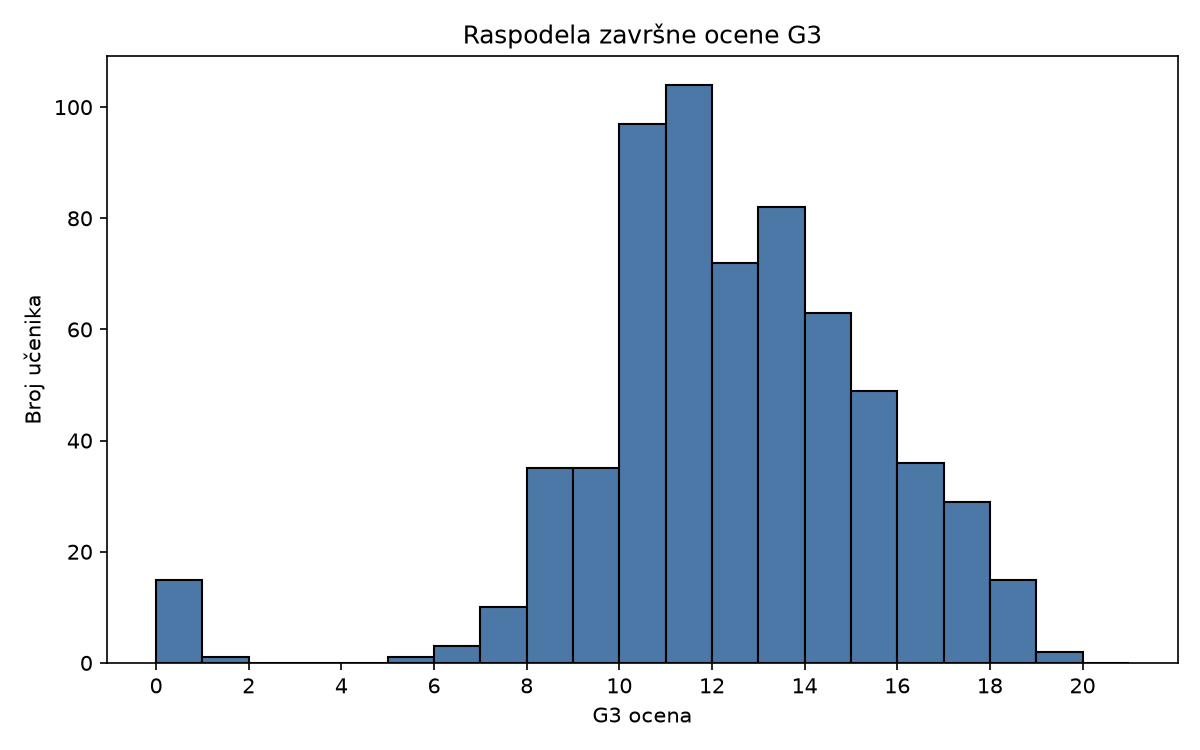

Korelaciona matrica


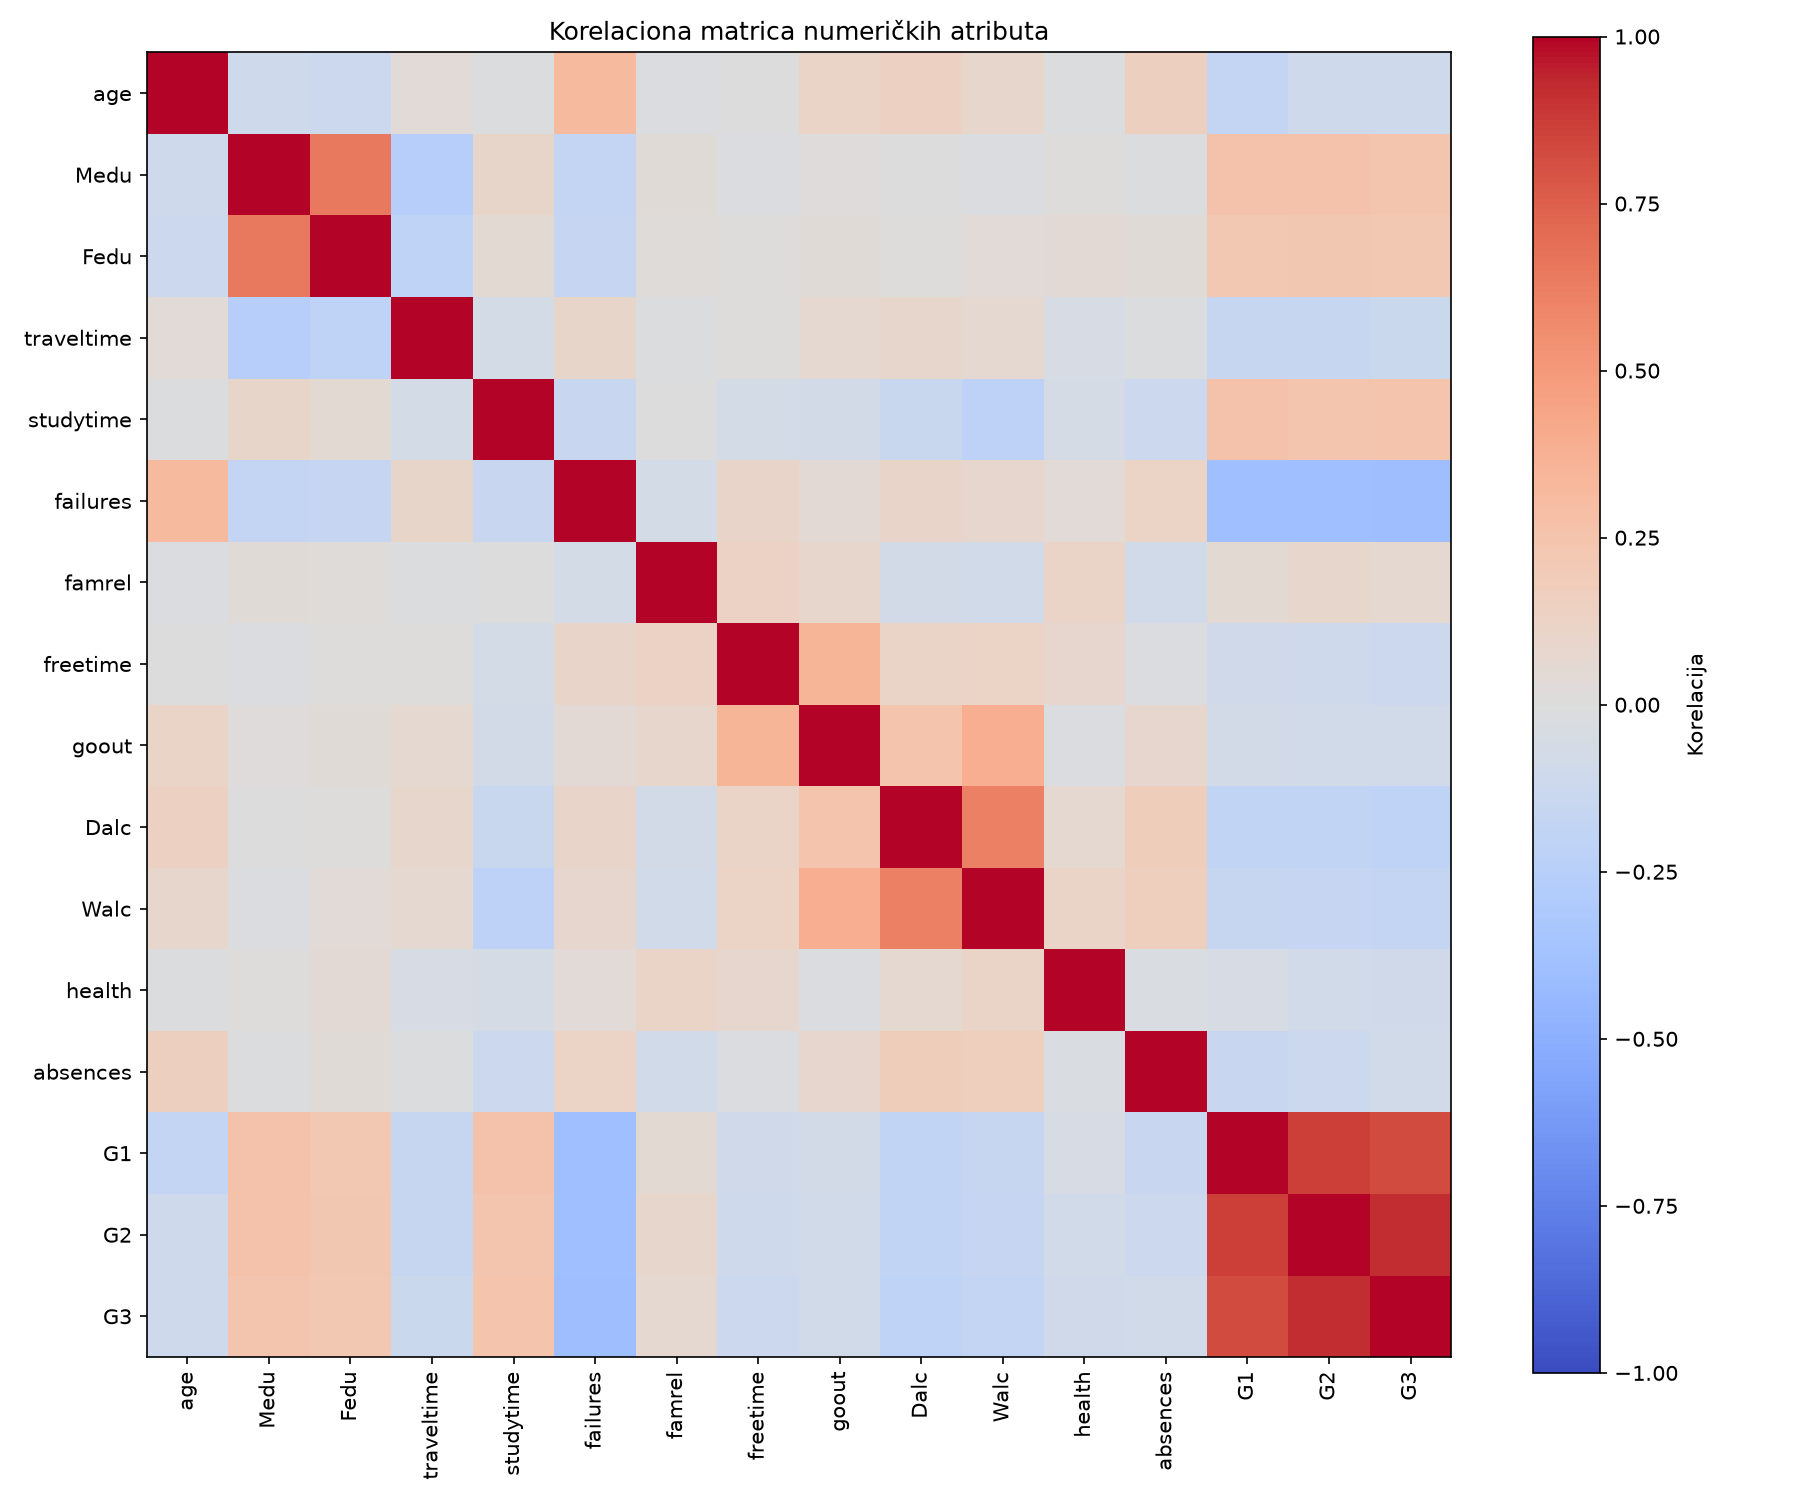

G1 vs G3


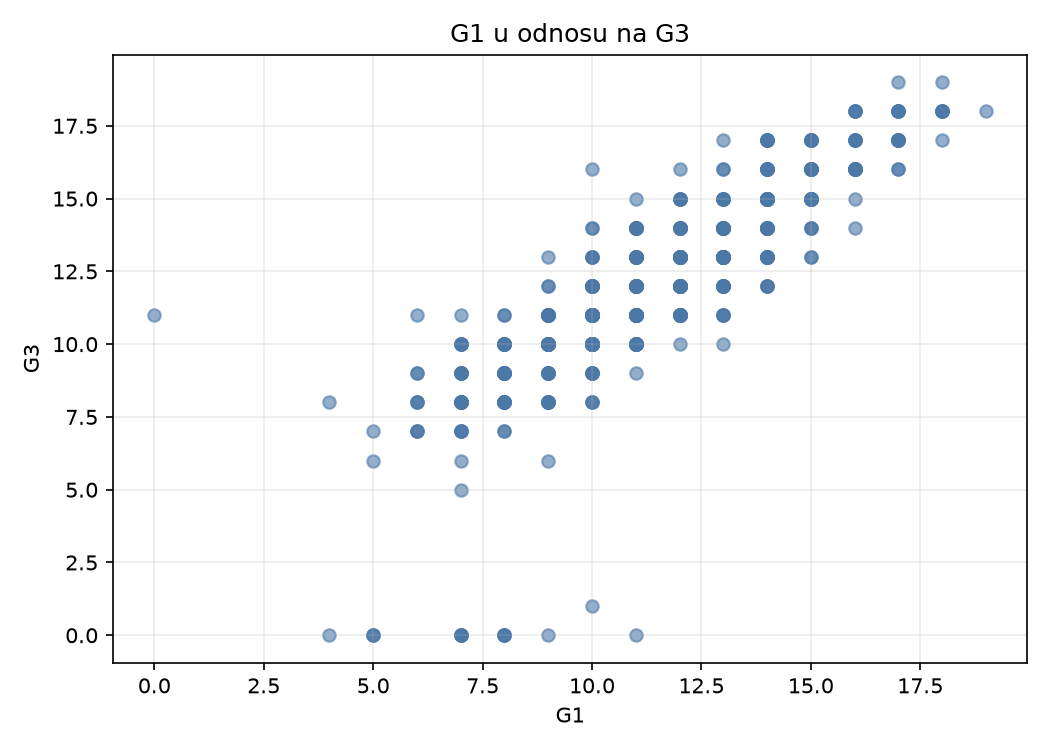

G2 vs G3


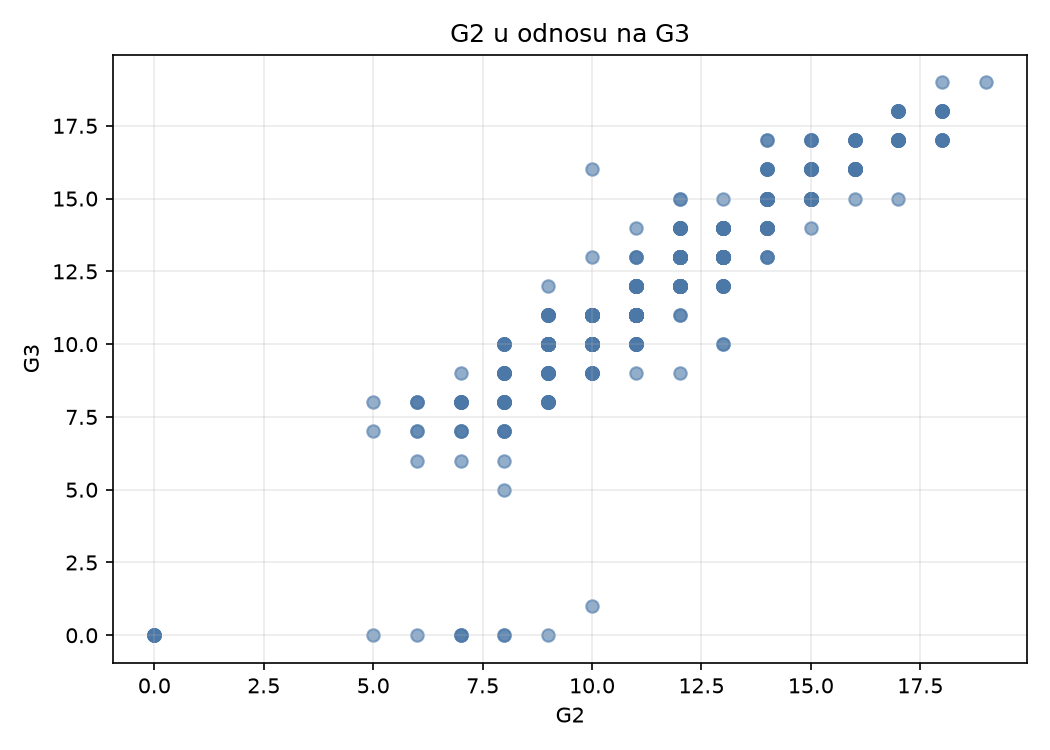

failures vs G3


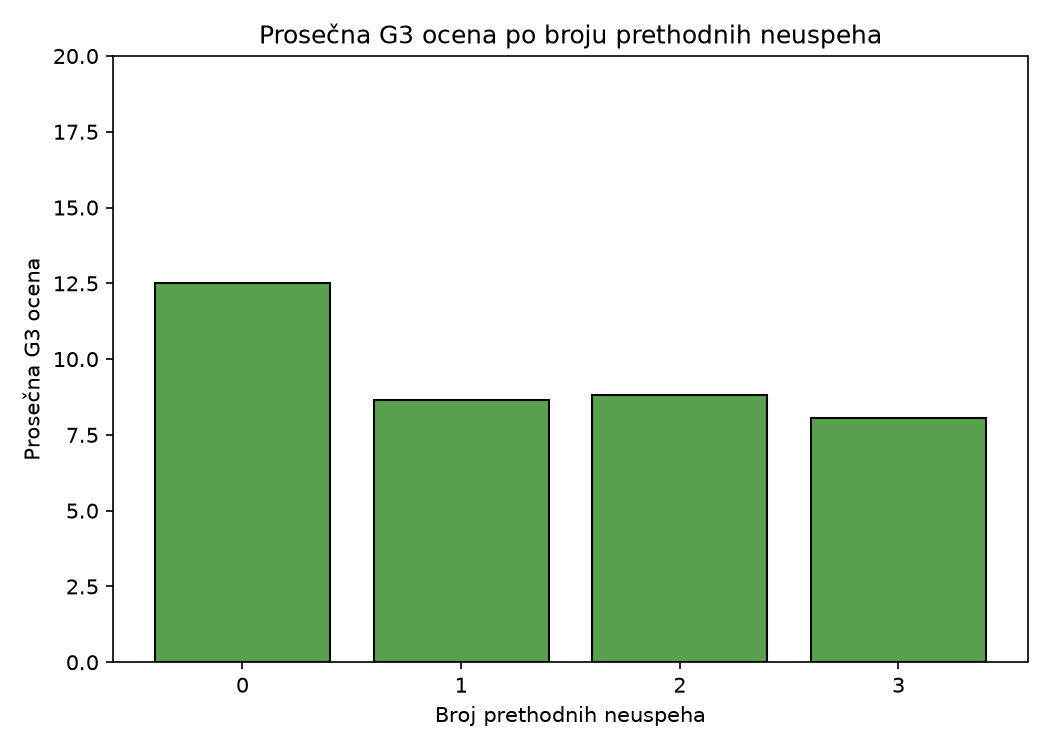

studytime vs G3


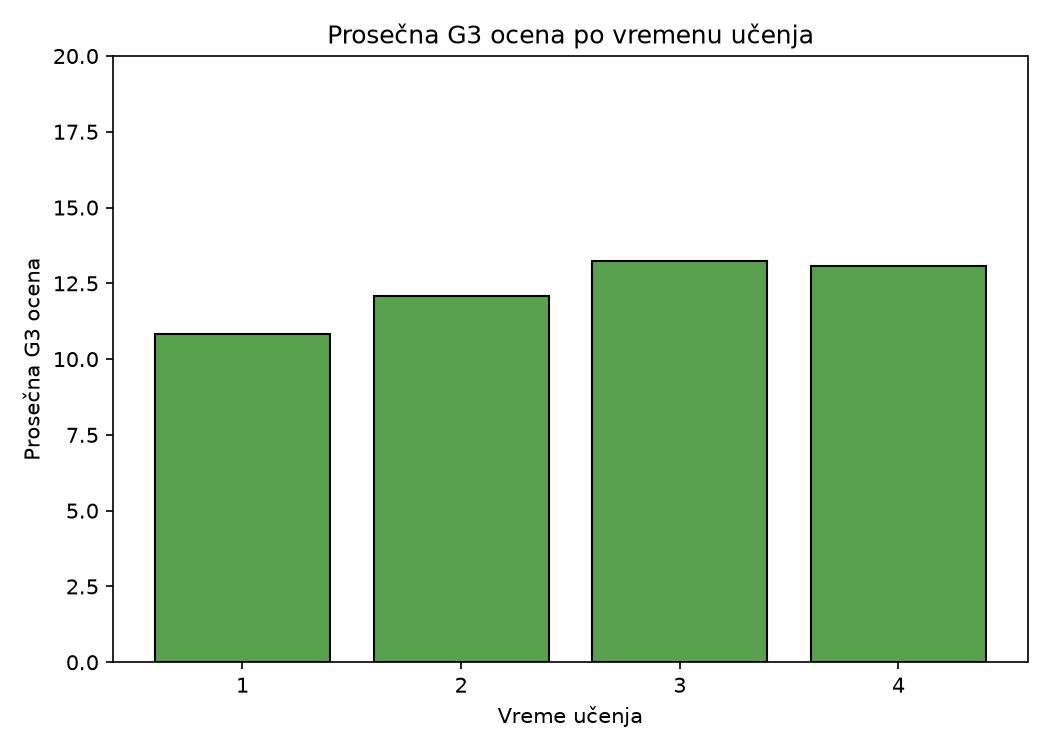

absences raspodela


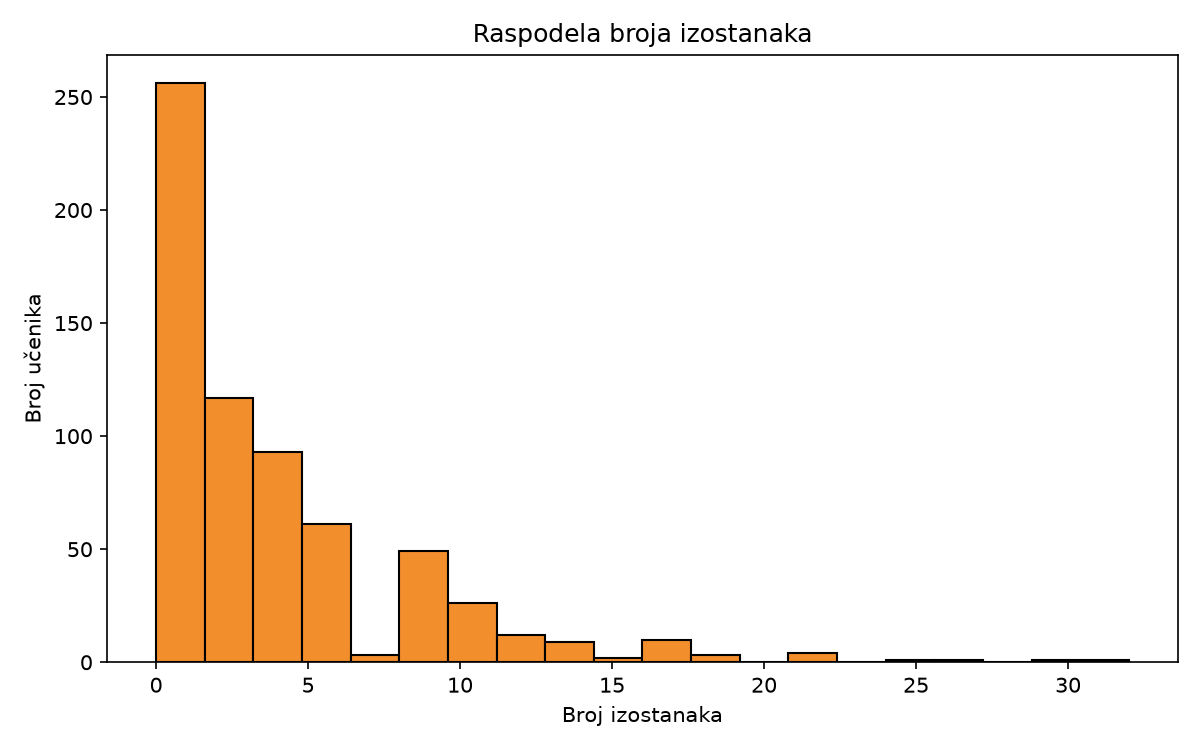

In [7]:
from IPython.display import Image, display

graph_paths = [
    ("Raspodela G3", STEP02_GRAPHS_DIR / "g3_distribution.png"),
    ("Korelaciona matrica", STEP02_GRAPHS_DIR / "numeric_correlation_matrix.png"),
    ("G1 vs G3", STEP02_GRAPHS_DIR / "g1_vs_g3.png"),
    ("G2 vs G3", STEP02_GRAPHS_DIR / "g2_vs_g3.png"),
    ("failures vs G3", STEP02_GRAPHS_DIR / "failures_vs_g3.png"),
    ("studytime vs G3", STEP02_GRAPHS_DIR / "studytime_vs_g3.png"),
    ("absences raspodela", STEP02_GRAPHS_DIR / "absences_distribution.png"),
]

for title, graph_path in graph_paths:
    print(title)
    display(Image(filename=str(graph_path)))


## Objasnjenje najvaznijih delova koda iz `step02_eda.py`

Ova sekcija izdvaja delove `step02_eda.py` koje je najvaznije razumeti za odbranu. Cilj nije da se prepisuje ceo fajl, vec da se jasno objasni sta EDA korak radi i zasto.

### 1. Definisanje putanja za podatke, grafike i logove

Na pocetku se definisu putanje do dataset-a, foldera za grafike i foldera za CSV izvestaje:

```python
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student-por.csv"
GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "step02_eda"
LOGS_DIR = PROJECT_ROOT / "data" / "logs" / "step02_eda"
```

Ovo omogucava da se svi rezultati EDA koraka cuvaju na jednom predvidljivom mestu: grafici u `data/graphs/step02_eda/`, a tekstualni izvestaj u `data/logs/step02_eda/`.

### 2. Ucitavanje dataset-a

Kao i u prvom koraku, podaci se ucitavaju iz `student-por.csv` pomocu pandas biblioteke:

```python
df = pd.read_csv(DATA_PATH)
```

EDA ne menja dataset, vec ga analizira kroz statistike, korelacije i grafike.

### 3. Raspodela ciljne promenljive G3

Funkcija `create_g3_distribution_graph` pravi histogram zavrsne ocene G3. Ovaj grafik pokazuje koliko ucenika ima koju zavrsnu ocenu na skali 0-20.

Ovo je vazno jer pre modelovanja treba razumeti da li je ciljna promenljiva ravnomerno rasporedjena, da li postoje ekstremne vrednosti i koliko ima slucajeva sa G3 = 0.

### 4. Korelaciona matrica numerickih atributa

U skripti se izdvajaju numericke kolone i racuna njihova korelacija:

```python
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()
```

Na osnovu te matrice pravi se `numeric_correlation_matrix.png`. Posebno se posmatraju korelacije G1-G3 i G2-G3, jer G1 i G2 predstavljaju prethodne ocene i ocekivano su najjace povezane sa zavrsnom ocenom.

### 5. Pojedinacni grafici za vazne atribute

Skripta pravi posebne grafike za:

- odnos `G1` i `G3`,
- odnos `G2` i `G3`,
- prosecnu G3 ocenu po broju prethodnih neuspeha (`failures`),
- prosecnu G3 ocenu po vremenu ucenja (`studytime`),
- raspodelu broja izostanaka (`absences`).

Ovi grafici pomazu da se korelacije i potencijalne anomalije ne vide samo kroz brojeve, vec i vizuelno.

### 6. Pravljenje `eda_report.csv`

Funkcija `create_eda_report` pravi kratak CSV izvestaj sa najvaznijim EDA nalazima: broj ucenika, minimalnu, maksimalnu i prosecnu G3 ocenu, broj i procenat ucenika sa G3 = 0, kljucne korelacije i najjacu korelaciju sa G3.

Na kraju se u izvestaj dodaje i zakljucak EDA analize. Time se rezultati drugog koraka mogu brzo procitati bez ponovnog tumacenja svih grafika.

### Kako bih ovo objasnio na odbrani?

U drugom koraku sam uradio eksplorativnu analizu podataka da bih razumeo kako su atributi povezani sa zavrsnom ocenom G3. Posebno sam gledao korelacije izmedju prethodnih ocena G1 i G2 i ciljne promenljive, jer one najvise uticu na kasnije modelovanje. Takodje sam proverio raspodelu ocene G3, broj izostanaka i slucajeve sa G3 = 0. Na osnovu ovih nalaza nisam brisao te vrednosti, jer mogu biti stvarni i vazni za model. Ovaj korak mi je pomogao da vidim koji atributi nose najvise informacija i da kasnije smisleno poredim modele sa i bez G1 i G2.

## Zakljucak posle drugog koraka

Posle drugog koraka imamo osnovnu EDA analizu dataset-a. Napravljeni su grafici za raspodelu G3, korelacije numerickih atributa, odnos G1/G2 sa G3, kao i pregled atributa `failures`, `studytime` i `absences`.

Prema trenutnom `eda_report.csv`, G1 i G2 su najjace povezani sa zavrsnom ocenom G3. Zbog toga je opravdano da kasnije poredimo modele sa G1 i G2 i modele bez G1 i G2.

Vrednosti G3 = 0 i vece vrednosti `absences` se za sada ne brisu. U ovom koraku ih samo evidentiramo, jer mogu predstavljati realne slucajeve u dataset-u. Odluka o eventualnoj dodatnoj obradi dolazi kasnije, kada se bude radilo modelovanje i evaluacija.